<h1><center>

</center></h1>
<font size="6"><center>
EIE 401
PROCESAMIENTO DIGITAL MULTIMEDIA 
</center></font>

<center><h2>Proyecto 1</h2></center>
<center><h3>Procesamiento digital de señales</h3></center>
<center><h3>Profesor: Jorge Cardenas</h3></center>

<center><h3>Por: Camilo Andrés Ladino Morales</h3></center>
<center><h5>Pontificia Universidad Catolica de Valparaiso</h5></center>

In [2]:
import os
import webbrowser

filePath = os.path.abspath('Proyecto_1_EIE401.pdf')   # construye la ruta absoluta al PDF
print('Abriendo:', filePath)                          # solo para verificar

webbrowser.open('file://' + filePath)                 # abre el PDF en el visor por defecto

Abriendo: G:\Mi unidad\EIE401-1-PROCESAMIENTO DIGITAL MULTIMEDIA(1S2026)\Proyecto\Proyecto_1_EIE401.pdf


True

In [3]:
# Mostrar el enunciado del Proyecto 1 dentro del notebook usando un visor PDF integrado
from IPython.display import IFrame, display

filePath = 'Proyecto_1_EIE401.pdf'  # Asegúrate de que este archivo esté en la misma carpeta que el notebook

# El objeto IFrame permite visualizar el PDF directamente en la celda
iframe = IFrame(filePath, width=900, height=600)
display(iframe)

Debes usar el sitio https://gwosc.org/eventapi/html/GWTC/, donde encuentras todo el catálogo de observaciones con los datos en diferentes formatos. Debes seleccionar una detección para tu estudio y descargar los datos correspondientes (H5 o TXT), lo que posteriormente deberás tratar de manera digital como audio (serie de tiempo).
tip: Te recomiendo tomar la serie de tiempo corta (32 segundos) para facilitar el análisis, y asegurarte de tomar la tasa de muestreo más alta.
tip: Asegúrate de tomar un caso cuyo espectrograma de muestra, indique una señal clara y fuerte para facilitar tu trabajo, de otra forma es posible que no logres aislarla lo suficiente.

# 1. Carga de Datos

En esta sección se cargan los datos originales del detector (por ejemplo H1) desde un archivo HDF5 descargado de GWOSC. 
Se construye el eje de tiempo y se realiza una primera visualización de la señal cruda en el dominio del tiempo.

In [4]:
# Instalar las librerías necesarias en el entorno actual de Jupyter
!pip install numpy matplotlib scipy h5py

In [5]:
# ============================
# Instalación de librerías necesarias con mensaje de estado
# ============================

import sys
import subprocess

try:
    print("Instalando dependencias... (numpy, matplotlib, scipy, h5py)")
    
    # Ejecuta pip usando el mismo intérprete de Python del kernel actual
    subprocess.check_call([
        sys.executable, "-m", "pip",
        "install", "numpy", "matplotlib", "scipy", "h5py"
    ])

    print("\nInstalación completada sin errores.")
except Exception as e:
    print("\nOcurrió un error durante la instalación:")
    print(e)

Instalando dependencias... (numpy, matplotlib, scipy, h5py)

Instalación completada sin errores.


Modo de carga seleccionado: HDF5
Archivo HDF5 configurado: H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5
Archivo TXT configurado: H-H1_GWOSC_4KHZ_R1-1126259447-32.txt
Directorio de datos: G:\Mi unidad\EIE401-1-PROCESAMIENTO DIGITAL MULTIMEDIA(1S2026)\Proyecto
Claves principales del archivo HDF5: ['meta', 'quality', 'strain']
Se encontró la señal en f['strain']['Strain']
No se encontró fs en atributos. Se usará fs_esperada = 4096 Hz
Archivo HDF5 cargado correctamente.
Número de muestras: 131072
Frecuencia de muestreo fs = 4096 Hz
Duración aproximada = 32.0 s


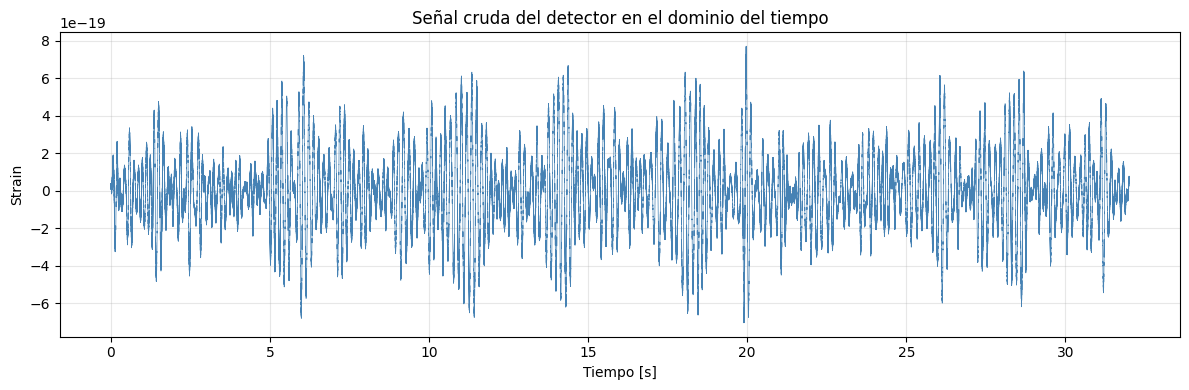

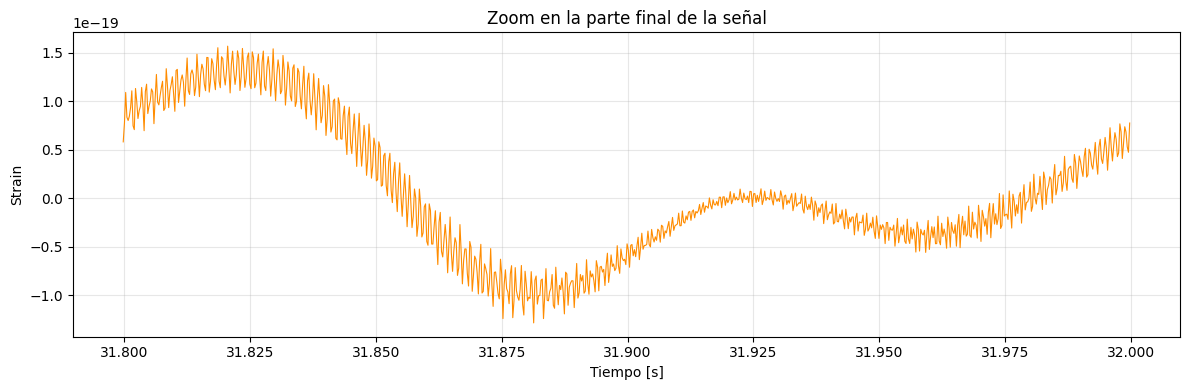

In [6]:
# ============================
# Importación de librerías
# ============================

import numpy as np                # Manejo de vectores y matrices numéricas
import matplotlib.pyplot as plt   # Gráficos 2D (líneas, espectrogramas, etc.)
from scipy import signal          # Funciones de procesamiento de señales
from scipy.io import wavfile      # Lectura y escritura de archivos WAV
import h5py                       # Lectura de archivos HDF5
import os                         # Manejo de rutas y sistema de archivos
import warnings                   # Control de advertencias

warnings.filterwarnings('ignore')  # Ocultar advertencias no críticas

# ============================
# Parámetros de usuario
# ============================

# Selección del tipo de archivo a cargar:
# True  -> usar archivo HDF5
# False -> usar archivo TXT
usar_hdf5 = True

# Nombre del archivo principal HDF5 (32 s, 4 kHz, detector H1)
nombre_archivo_hdf5 = 'H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5'

# Nombre del archivo TXT alternativo

nombre_archivo_txt = 'H-H1_GWOSC_4KHZ_R1-1126259447-32.txt'

# Carpeta donde se buscarán los archivos
directorio_datos = '.'

# Tasa de muestreo esperada si el archivo no la trae explícita
fs_esperada = 4096  # Hz

print('Modo de carga seleccionado:', 'HDF5' if usar_hdf5 else 'TXT')
print('Archivo HDF5 configurado:', nombre_archivo_hdf5)
print('Archivo TXT configurado:', nombre_archivo_txt)
print('Directorio de datos:', os.path.abspath(directorio_datos))

# ============================
# Función para cargar desde HDF5
# ============================

def cargar_desde_hdf5(nombre_archivo, carpeta='.'):
    """
    Carga una señal desde un archivo HDF5 de LIGO/GWOSC.
    
    Retorna:
    t  -> vector de tiempo
    h  -> señal strain
    fs -> frecuencia de muestreo
    """
    
    # Construir la ruta completa al archivo
    ruta_archivo = os.path.join(carpeta, nombre_archivo)

    # Verificar que el archivo exista
    if not os.path.exists(ruta_archivo):
        raise FileNotFoundError('No se encontró el archivo HDF5 en la ruta: ' + ruta_archivo)

    # Abrir el archivo en modo lectura
    with h5py.File(ruta_archivo, 'r') as f:
        # Mostrar claves principales para inspeccionar la estructura
        print('Claves principales del archivo HDF5:', list(f.keys()))

        # Inicializar variable donde se guardará el dataset
        h_dataset = None

        # Caso más común en archivos GWOSC: grupo strain con dataset Strain
        if 'strain' in f and 'Strain' in f['strain']:
            h_dataset = f['strain']['Strain']
            print("Se encontró la señal en f['strain']['Strain']")

        # Caso alternativo: strain directamente como dataset
        elif 'strain' in f:
            h_dataset = f['strain']
            print("Se encontró la señal directamente en f['strain']")

        # Si no se encuentra, lanzar error
        else:
            raise ValueError('No se encontró el dataset de strain en el archivo HDF5.')

        # Convertir el dataset HDF5 a un arreglo NumPy
        h = h_dataset[...]

        # Intentar obtener la frecuencia de muestreo desde atributos
        fs = None

        if 'sampling_rate' in h_dataset.attrs:
            fs = h_dataset.attrs['sampling_rate']
        elif 'sample_rate' in h_dataset.attrs:
            fs = h_dataset.attrs['sample_rate']

        # Si no aparece en el dataset, buscar en el grupo strain
        if fs is None and 'strain' in f and hasattr(f['strain'], 'attrs'):
            if 'sampling_rate' in f['strain'].attrs:
                fs = f['strain'].attrs['sampling_rate']
            elif 'sample_rate' in f['strain'].attrs:
                fs = f['strain'].attrs['sample_rate']

        # Si aun así no aparece, usar la frecuencia esperada
        if fs is None:
            print('No se encontró fs en atributos. Se usará fs_esperada =', fs_esperada, 'Hz')
            fs = fs_esperada

    # Construir eje de tiempo
    n = len(h)                   # Número de muestras
    dt = 1.0 / fs                # Intervalo de muestreo
    t = np.arange(0, n * dt, dt) # Vector de tiempo

    # Ajuste por seguridad si el tamaño difiere por redondeo
    if len(t) > n:
        t = t[:n]

    # Mensaje resumen
    print('Archivo HDF5 cargado correctamente.')
    print('Número de muestras:', n)
    print('Frecuencia de muestreo fs =', fs, 'Hz')
    print('Duración aproximada =', n / fs, 's')

    return t, h, fs

# ============================
# Función para cargar desde TXT
# ============================

def cargar_desde_txt(nombre_archivo, carpeta='.'):
    """
    Carga una señal desde un archivo TXT.

    Se asumen dos formatos posibles:
    1) Una sola columna: contiene solo la señal strain
    2) Dos columnas: tiempo y strain

    Retorna:
    t  -> vector de tiempo
    h  -> señal strain
    fs -> frecuencia de muestreo
    """
    
    # Construir la ruta completa al archivo
    ruta_archivo = os.path.join(carpeta, nombre_archivo)

    # Verificar que el archivo exista
    if not os.path.exists(ruta_archivo):
        raise FileNotFoundError('No se encontró el archivo TXT en la ruta: ' + ruta_archivo)

    # Cargar datos numéricos desde el TXT
    datos = np.loadtxt(ruta_archivo)

    # Caso 1: una sola columna
    if datos.ndim == 1:
        h = datos
        fs = fs_esperada
        n = len(h)
        dt = 1.0 / fs
        t = np.arange(0, n * dt, dt)

        print('El TXT contiene una sola columna.')
        print('Se asumirá que corresponde solo a la señal strain.')
        print('Se usará fs_esperada =', fs, 'Hz')

    # Caso 2: dos o más columnas
    else:
        t = datos[:, 0]
        h = datos[:, 1]

        # Estimar frecuencia de muestreo a partir del tiempo
        dt = np.mean(np.diff(t))
        fs = 1.0 / dt

        print('El TXT contiene al menos dos columnas.')
        print('Se interpretará la primera como tiempo y la segunda como strain.')

    # Ajuste por seguridad
    n = len(h)
    if len(t) > n:
        t = t[:n]

    # Mensaje resumen
    print('Archivo TXT cargado correctamente.')
    print('Número de muestras:', n)
    print('Frecuencia de muestreo fs ≈', fs, 'Hz')
    print('Duración aproximada =', n / fs, 's')

    return t, h, fs

# ============================
# Carga principal del archivo seleccionado
# ============================

try:
    if usar_hdf5:
        t, h, fs = cargar_desde_hdf5(nombre_archivo_hdf5, directorio_datos)
    else:
        t, h, fs = cargar_desde_txt(nombre_archivo_txt, directorio_datos)

except Exception as e:
    print('Error durante la carga de datos:')
    print(e)
    raise

# ============================
# Visualización básica en el dominio del tiempo
# ============================

plt.figure(figsize=(12, 4))
plt.plot(t, h, color='steelblue', linewidth=0.5)
plt.title('Señal cruda del detector en el dominio del tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Strain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================
# Zoom en la parte final de la señal
# ============================

ventana_zoom = 0.2                  # Duración del zoom en segundos
inicio_zoom = t[-1] - ventana_zoom  # Tiempo inicial del zoom

mascara_zoom = (t >= inicio_zoom) & (t <= t[-1])

plt.figure(figsize=(12, 4))
plt.plot(t[mascara_zoom], h[mascara_zoom], color='darkorange', linewidth=0.8)
plt.title('Zoom en la parte final de la señal')
plt.xlabel('Tiempo [s]')
plt.ylabel('Strain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Convertir en audio

En esta sección se normaliza la señal y se guarda en un archivo de audio `.wav` para poder escuchar el chirp como un deslizamiento de frecuencia.

In [7]:
# ======================================
# 2. Convertir en audio (.wav)
# ======================================

# Verificar que las variables necesarias existen en el entorno
# h  -> señal en el tiempo (strain)
# fs -> frecuencia de muestreo original
if 'h' not in globals() or 'fs' not in globals():
    raise RuntimeError(
        "Las variables 'h' o 'fs' no están definidas. "
        "Ejecuta primero la sección de Carga de Datos."
    )

# ---------------------------------------------------------
# Normalización de la señal para uso como audio
# ---------------------------------------------------------

# Calcular el valor máximo absoluto de la señal
# Esto se usa para escalar la señal al rango [-1, 1]
max_abs = np.max(np.abs(h))

if max_abs == 0:
    # Si la señal es completamente cero (caso muy raro),
    # se copia tal cual para evitar división por cero
    h_norm = h.copy()
    print("Advertencia: la señal es completamente cero; no se aplica normalización.")
else:
    # Dividir toda la señal por su máximo absoluto
    # Esto garantiza que el valor absoluto máximo sea 1
    h_norm = h / max_abs

# ---------------------------------------------------------
# Definir nombre y ruta del archivo de audio de salida
# ---------------------------------------------------------

# Nombre del archivo WAV que se generará
nombre_wav = "H1_evento_chirp_original_fs.wav"

# Construir la ruta completa usando el mismo directorio de datos
ruta_wav = os.path.join(directorio_datos, nombre_wav)

# ---------------------------------------------------------
# Guardar el archivo WAV
# ---------------------------------------------------------

# Guardar usando la frecuencia de muestreo original fs
# El formato float32 es adecuado para señales científicas normalizadas
wavfile.write(ruta_wav, int(fs), h_norm.astype(np.float32))

# Mensajes informativos para el usuario
print("Archivo de audio generado (fs original) en:")
print("   ", ruta_wav)
print("Frecuencia de muestreo:", fs, "Hz")
print("Duración aproximada:", len(h_norm) / fs, "segundos")

# ---------------------------------------------------------
# Comentario para el informe:
# En esta etapa solo se convierte la señal cruda a audio,
# sin aplicar todavía whitening ni filtrado. El objetivo es
# poder escuchar cómo suena el ruido del detector y, en algunos
# casos, un chirp débilmente perceptible.
# ---------------------------------------------------------


Archivo de audio generado (fs original) en:
    .\H1_evento_chirp_original_fs.wav
Frecuencia de muestreo: 4096 Hz
Duración aproximada: 32.0 segundos


# 3. Análisis de Fourier

En esta sección se estudia el contenido espectral de la señal mediante la Densidad Espectral de Potencia (PSD) usando el método de Welch, 
y se realiza una inspección rápida con la Transformada de Fourier.

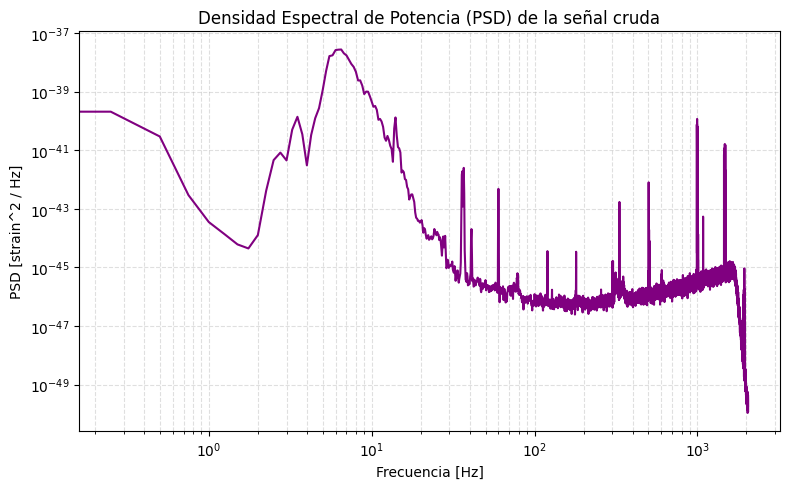

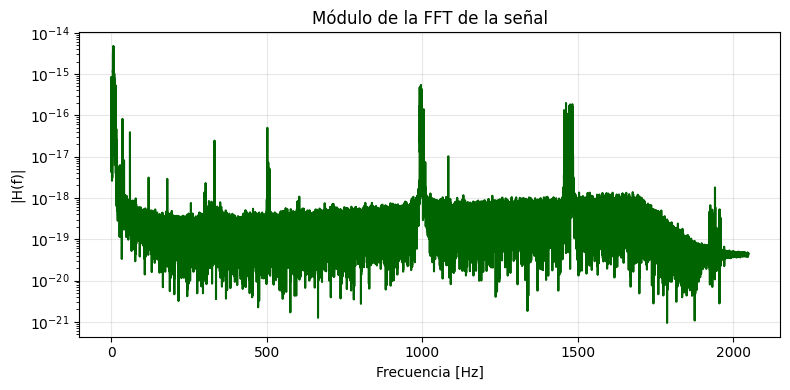

In [8]:
# ======================================
# 3. Análisis de Fourier (PSD + FFT)
# ======================================

# Comprobar que la señal y la tasa de muestreo estén disponibles.
# h  -> señal en el dominio del tiempo (strain)
# fs -> frecuencia de muestreo de la señal
if 'h' not in globals() or 'fs' not in globals():
    raise RuntimeError(
        "Las variables 'h' o 'fs' no están definidas. "
        "Ejecuta primero la sección de Carga de Datos."
    )

# ---------------------------------------------------------
# Cálculo de la PSD usando el método de Welch
# ---------------------------------------------------------

# Definir la duración de cada segmento de análisis para Welch (en segundos).
# Segmentar la señal y promediar varias PSD reduce la varianza del estimador.
segundos_segmento = 4.0

# Convertir la duración del segmento a número de muestras.
# nperseg es el tamaño de ventana que usará Welch.
nperseg = int(segundos_segmento * fs)

# Calcular la PSD.
# frecuencias -> vector de frecuencias en Hz
# psd         -> densidad espectral de potencia estimada en cada frecuencia
frecuencias, psd = signal.welch(h, fs=fs, nperseg=nperseg)

# Graficar la PSD en escala log-log.
plt.figure(figsize=(8, 5))
plt.loglog(frecuencias, psd, color='purple')
plt.title('Densidad Espectral de Potencia (PSD) de la señal cruda')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [strain^2 / Hz]')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FFT de la señal completa (espectro de una sola realización)
# ---------------------------------------------------------

# Número total de muestras de la señal.
N = len(h)

# Calcular la FFT real de la señal.
# np.fft.rfft devuelve solo las frecuencias positivas (aprovechando que h es real).
H_f = np.fft.rfft(h)

# Calcular el vector de frecuencias asociado a la FFT.
freqs_fft = np.fft.rfftfreq(N, d=1.0 / fs)

# Graficar el módulo de la FFT en escala semilogarítmica.
plt.figure(figsize=(8, 4))
plt.semilogy(freqs_fft, np.abs(H_f), color='darkgreen')
plt.title('Módulo de la FFT de la señal')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)|')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comentario para el informe:
# - La PSD (Welch) muestra cómo se distribuye la potencia de la señal en frecuencia
#   promediando varios segmentos para reducir el ruido del estimador.
# - La FFT muestra el espectro de una sola realización de la señal completa,
#   útil para ver picos específicos pero más sensible al ruido.


# 4. Procesamiento

En esta sección se realiza el blanqueo (*whitening*) de la señal utilizando la PSD estimada y luego se aplica un filtro pasa-banda 
para resaltar el chirp. Finalmente se generan espectrogramas antes y después del procesamiento y se localiza el instante aproximado del chirp.

Whitening aplicado correctamente a la señal.
Filtro pasa-banda Butterworth de orden 4 aplicado en [30.0, 350.0] Hz.


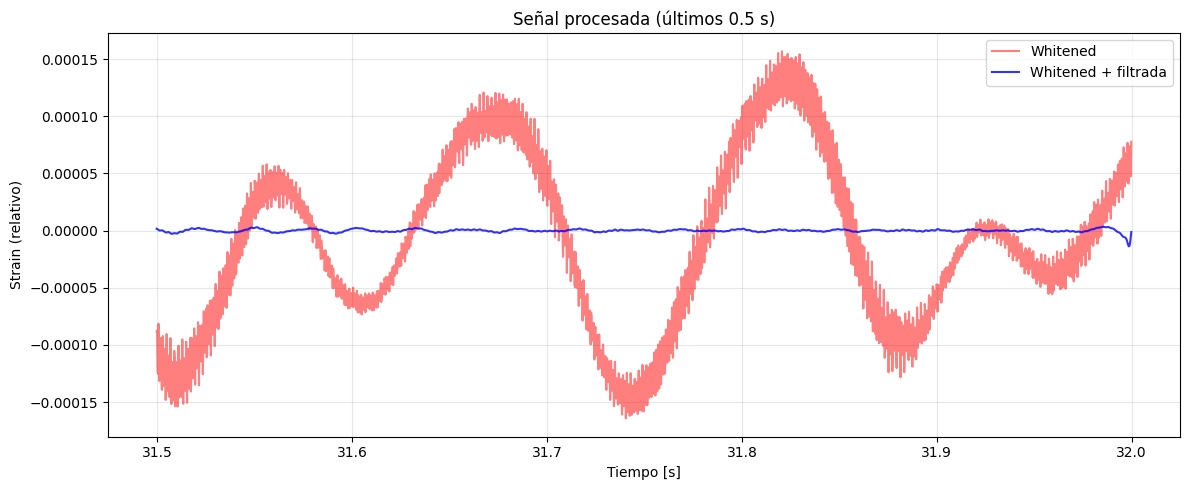

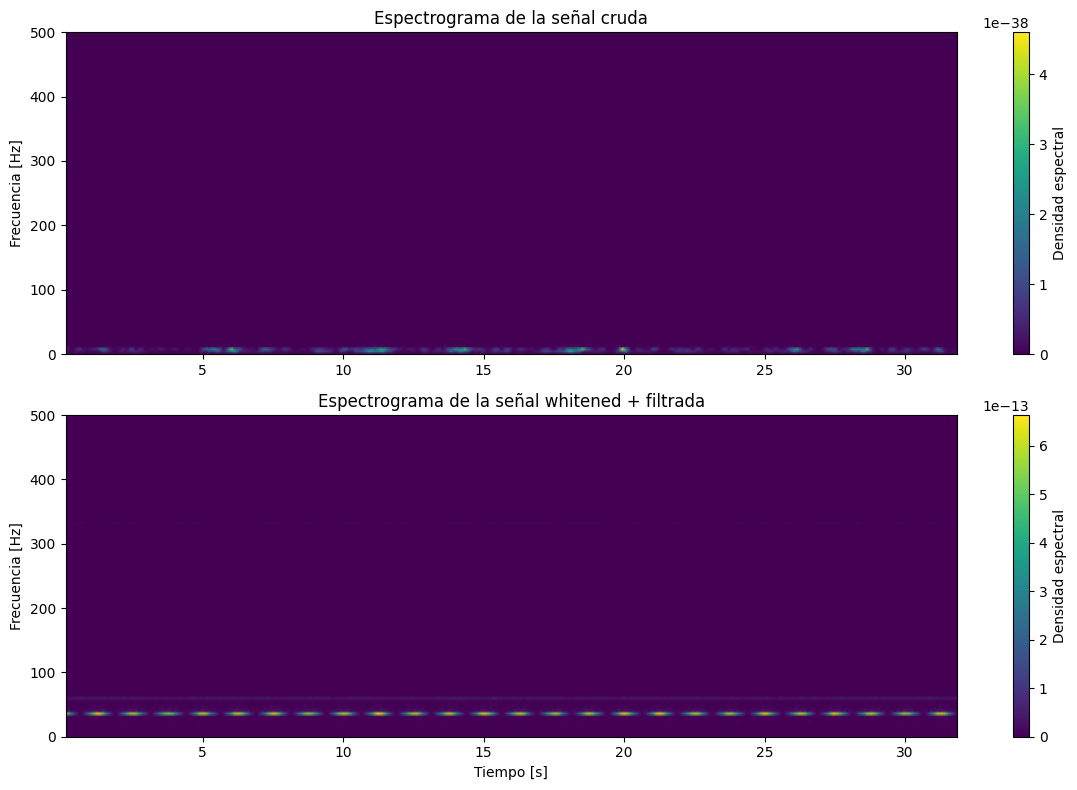

Máximo de la señal procesada en t = 31.998535 s


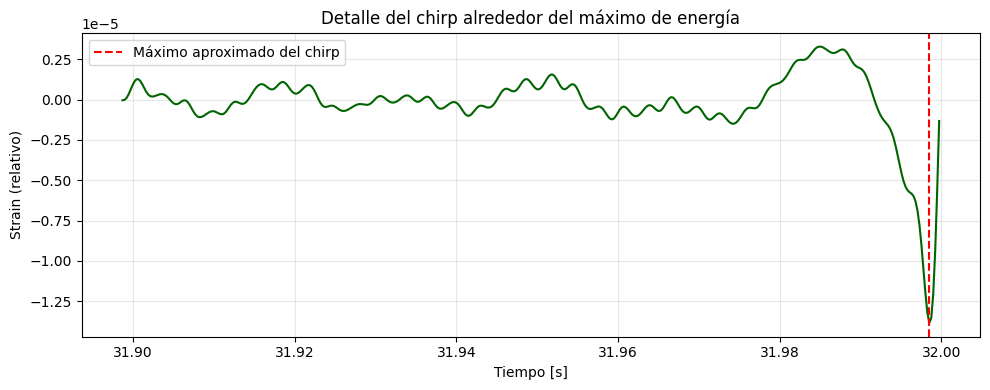

In [9]:
# ======================================
# 4. Procesamiento de la señal
# Whitening + filtro pasa-banda + espectrogramas
# ======================================

# Verificar que existan las variables necesarias para el procesamiento.
# h           -> señal cruda en el dominio del tiempo
# fs          -> frecuencia de muestreo
# frecuencias -> frecuencias de la PSD (calculadas con Welch)
# psd         -> valores de PSD asociados a 'frecuencias'
if ('h' not in globals() or 'fs' not in globals() or
    'frecuencias' not in globals() or 'psd' not in globals()):
    raise RuntimeError(
        "Faltan variables para el procesamiento (h, fs, frecuencias, psd). "
        "Ejecuta primero las secciones de Carga de Datos y Análisis de Fourier."
    )

# ---------------------------------------------------------
# 4.1 Whitening de la señal usando la PSD
# ---------------------------------------------------------

# El whitening consiste en igualar (aproximadamente) la energía de la señal
# en todas las frecuencias, dividiendo el espectro por la raíz de la PSD.

# Número de muestras de la señal
N = len(h)

# FFT real de la señal cruda
H_f = np.fft.rfft(h)

# Vector de frecuencias asociado a la FFT
freqs_fft = np.fft.rfftfreq(N, d=1.0 / fs)

# Interpolar la PSD calculada con Welch a las frecuencias de la FFT
psd_interp = np.interp(freqs_fft, frecuencias, psd)

# Definir un piso mínimo para la PSD (evita división por cero)
psd_floor = 1e-30
psd_interp = np.maximum(psd_interp, psd_floor)

# Aplicar whitening dividiendo por la raíz cuadrada de la PSD interpolada
H_white = H_f / np.sqrt(psd_interp)

# Volver al dominio del tiempo mediante la IFFT real
h_white = np.fft.irfft(H_white, n=N)

print("Whitening aplicado correctamente a la señal.")

# ---------------------------------------------------------
# 4.2 Diseño y aplicación de un filtro pasa-banda
# ---------------------------------------------------------

# Definir las frecuencias de corte del filtro pasa-banda (en Hz).
# Este rango se elige alrededor de la banda donde se espera el chirp.
f_low = 30.0    # frecuencia de corte baja (Hz)
f_high = 350.0  # frecuencia de corte alta (Hz)

# Calcular la frecuencia de Nyquist (mitad de fs)
f_nyquist = 0.5 * fs

# Normalizar las frecuencias de corte al rango [0, 1] para butter()
low = f_low / f_nyquist
high = f_high / f_nyquist

# Orden del filtro Butterworth
orden = 4

# Calcular los coeficientes del filtro pasa-banda Butterworth
b, a = signal.butter(orden, [low, high], btype='band')

# Aplicar el filtro de manera acausal (filtfilt) para no introducir desfase
h_white_filt = signal.filtfilt(b, a, h_white)

print(f"Filtro pasa-banda Butterworth de orden {orden} aplicado en [{f_low}, {f_high}] Hz.")

# ---------------------------------------------------------
# 4.3 Comparación temporal en los últimos segundos
# ---------------------------------------------------------

# Definir una ventana en los últimos segundos para ver mejor el chirp
ventana_plot = 0.5  # duración de la ventana en segundos
inicio = t[-1] - ventana_plot

# Máscara booleana para seleccionar solo la parte final de la señal
mascara = (t >= inicio) & (t <= t[-1])

plt.figure(figsize=(12, 5))
plt.plot(t[mascara], h_white[mascara], label='Whitened', color='red', alpha=0.5)
plt.plot(t[mascara], h_white_filt[mascara], label='Whitened + filtrada', color='blue', alpha=0.8)
plt.title(f'Señal procesada (últimos {ventana_plot} s)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Strain (relativo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4.4 Espectrogramas antes y después del procesamiento
# ---------------------------------------------------------

# Parámetros para el cálculo de espectrogramas
nperseg_spec = int(0.25 * fs)   # duración de cada segmento (0.25 s)
noverlap_spec = int(0.15 * fs)  # solapamiento entre segmentos (0.15 s)

# Espectrograma de la señal cruda
f_raw, t_raw, Sxx_raw = signal.spectrogram(
    h, fs=fs, nperseg=nperseg_spec, noverlap=noverlap_spec
)

# Espectrograma de la señal whitened + filtrada
f_proc, t_proc, Sxx_proc = signal.spectrogram(
    h_white_filt, fs=fs, nperseg=nperseg_spec, noverlap=noverlap_spec
)

plt.figure(figsize=(12, 8))

# Subgráfico 1: señal cruda
plt.subplot(2, 1, 1)
plt.pcolormesh(t_raw, f_raw, Sxx_raw, shading='gouraud')
plt.title('Espectrograma de la señal cruda')
plt.ylabel('Frecuencia [Hz]')
plt.colorbar(label='Densidad espectral')
plt.ylim(0, 500)

# Subgráfico 2: señal procesada
plt.subplot(2, 1, 2)
plt.pcolormesh(t_proc, f_proc, Sxx_proc, shading='gouraud')
plt.title('Espectrograma de la señal whitened + filtrada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Frecuencia [Hz]')
plt.colorbar(label='Densidad espectral')
plt.ylim(0, 500)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4.5 Localización aproximada del chirp
# ---------------------------------------------------------

# Encontrar el índice donde la señal procesada alcanza su máximo valor absoluto
idx_max = int(np.argmax(np.abs(h_white_filt)))
t_max = float(t[idx_max])

print("Máximo de la señal procesada en t =", round(t_max, 6), "s")

# Definir una pequeña ventana alrededor de ese máximo para ver el chirp en detalle
ventana_chirp = 0.1  # segundos a cada lado del máximo
ini = t_max - ventana_chirp
fin = t_max + ventana_chirp

mascara_chirp = (t >= ini) & (t <= fin)

plt.figure(figsize=(10, 4))
plt.plot(t[mascara_chirp], h_white_filt[mascara_chirp], color='darkgreen')
plt.axvline(t_max, color='red', linestyle='--', label='Máximo aproximado del chirp')
plt.title('Detalle del chirp alrededor del máximo de energía')
plt.xlabel('Tiempo [s]')
plt.ylabel('Strain (relativo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comentario para el informe:
# - Whitening reduce la dependencia de la sensibilidad del detector con la frecuencia.
# - El filtro pasa-banda concentra la atención en la banda donde el chirp es más fuerte.
# - El espectrograma procesado debería mostrar claramente el incremento de frecuencia
#   característico del chirp, más visible que en el espectrograma crudo.

# Resampling

Para lograr una mejor definición de la señal audible, en esta sección puedes realizar un cambio de tasa de muestreo (*resampling*). 
Por ejemplo, puedes llevar la señal filtrada a una tasa más baja adecuada para audio (por ejemplo 8192 Hz o 44100 Hz) usando `scipy.signal.resample` o `decimate`.

In [10]:

# ======================================
# Resampling (cambio de tasa de muestreo)
# ======================================

# Objetivo:
# Mejorar la "definición audible" del chirp generando un archivo de audio
# con una tasa de muestreo más típica para audio (por ejemplo 44100 Hz).
# IMPORTANTE: el resampling no aumenta la información, solo cambia cómo
# se distribuyen las muestras en el tiempo. También hay que cuidar no
# introducir ruido o aliasing.

# Verificar que existan la señal procesada y la frecuencia de muestreo original
if 'h_white_filt' not in globals() or 'fs' not in globals():
    raise RuntimeError(
        "No existe la señal procesada 'h_white_filt' o la tasa de muestreo 'fs'. "
        "Ejecuta primero la sección de Procesamiento." )

# ---------------------------------------------------------
# Definir la nueva tasa de muestreo deseada
# ---------------------------------------------------------

# Tasa típica de audio para buena calidad (puedes usar 8192, 11025, 22050, 44100, etc.)
fs_nueva = 44100  # Hz

print("Frecuencia de muestreo original fs =", fs, "Hz")
print("Nueva frecuencia de muestreo fs_nueva =", fs_nueva, "Hz")

# ---------------------------------------------------------
# Calcular el número de muestras después del resampling
# ---------------------------------------------------------

# Número de muestras actuales de la señal procesada
n_actual = len(h_white_filt)

# Número de muestras deseado tras el cambio de tasa de muestreo
# Proporción: n_nuevo / n_actual ≈ fs_nueva / fs
n_nuevo = int(n_actual * fs_nueva / fs)

print("Número de muestras original:", n_actual)
print("Número de muestras después de resampling:", n_nuevo)

# ---------------------------------------------------------
# Aplicar resampling a la señal procesada
# ---------------------------------------------------------

# Resamplear la señal usando scipy.signal.resample
# Esta función reinterpolar la señal a un nuevo número de puntos
h_resamp = signal.resample(h_white_filt, n_nuevo)

# ---------------------------------------------------------
# Normalización y posible amplificación para audio
# ---------------------------------------------------------

# Calcular el valor máximo absoluto de la señal resampleada
max_abs = np.max(np.abs(h_resamp))

if max_abs > 0:
    # Normalizar para que el máximo absoluto sea 1
    h_resamp = h_resamp / max_abs

    # Aplicar un factor de ganancia para que suene más fuerte,
    # pero sin saturar (dejamos un margen del 10 %)
    factor_ganancia = 0.9
    h_resamp = factor_ganancia * h_resamp
else:
    print("Advertencia: la señal resampleada es cero; no se aplica normalización.")

# ---------------------------------------------------------
# Guardar la señal resampleada como archivo WAV
# ---------------------------------------------------------

nombre_wav_resamp = "H1_evento_chirp_resampled_44100Hz.wav"
ruta_wav_resamp = os.path.join(directorio_datos, nombre_wav_resamp)

# Guardar en formato float32 para audio científico
wavfile.write(ruta_wav_resamp, int(fs_nueva), h_resamp.astype(np.float32))

print("Archivo de audio resampleado guardado en:")
print("   ", ruta_wav_resamp)
print("Duración aproximada:", len(h_resamp) / fs_nueva, "segundos")

# Comentario para el informe:
# - El resampling a 44100 Hz permite escuchar el chirp en reproductores
#   de audio estándar con mejor resolución temporal.
# - La normalización y la ganancia controlada evitan que el archivo
#   quede inaudible o saturado.
# - Es importante mencionar que el contenido espectral útil sigue
#   limitado por la banda de trabajo del detector; no se "crea"
#   información nueva al aumentar fs.


Frecuencia de muestreo original fs = 4096 Hz
Nueva frecuencia de muestreo fs_nueva = 44100 Hz
Número de muestras original: 131072
Número de muestras después de resampling: 1411200
Archivo de audio resampleado guardado en:
    .\H1_evento_chirp_resampled_44100Hz.wav
Duración aproximada: 32.0 segundos


In [11]:
# Mostrar el enunciado del Proyecto 1 dentro del notebook usando un visor PDF integrado
from IPython.display import IFrame, display

filePath = 'Proyecto1.pdf'  # Asegúrate de que este archivo esté en la misma carpeta que el notebook

# El objeto IFrame permite visualizar el PDF directamente en la celda
iframe = IFrame(filePath, width=900, height=600)
display(iframe)

In [12]:
import os
import webbrowser

filePath = os.path.abspath('Proyecto1.pdf')   # construye la ruta absoluta al PDF
print('Abriendo:', filePath)                          # solo para verificar

webbrowser.open('file://' + filePath)                 # abre el PDF en el visor por defecto

Abriendo: G:\Mi unidad\EIE401-1-PROCESAMIENTO DIGITAL MULTIMEDIA(1S2026)\Proyecto\Proyecto1.pdf


True